# Predição de Bolsas CNPq — Pipeline Unificada
Este notebook consolida todas as versões anteriores numa única pipeline modular.

## Modelos incluídos
| Modelo | Pré-processamento | Otimização |
|---|---|---|
| Ridge (baseline) | TF-IDF + OrdinalEncoder + TargetEncoder | — |
| XGBoost | TF-IDF + OrdinalEncoder + TargetEncoder | Optuna |
| LightGBM | TF-IDF + OrdinalEncoder + TargetEncoder | Optuna |
| TABPFN-3 | Modelo pré-treinado | Modelo pré-treinado |

## Estrutura
1. Imports e configurações globais  
2. Carregamento e pré-processamento  
3. Feature engineering  
4. Preprocessador (TF-IDF / Encoders)  
5. Modelos — treino, Optuna e avaliação  
6. Tabela comparativa final  


## H1:
Técnicas de aprendizado de máquina podem ser utilizadas para
prever tendências futuras de investimento científico com base em dados
históricos de fomento do CNPq



## 1. Imports e configurações globais

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import os
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

from tabpfn import TabPFNRegressor



In [ ]:
#Configurações globais 
ARQUIVO_PARQUET = "dados/cnpqBolsasAuxilios_limpo.parquet"
TARGET          = "valor_pago"
N_SAMPLE        = 3000000     # 30 mil linhas para acelerar o desenvolvimento 
RANDOM_STATE    = 67
N_TRIALS_XGB    = 50        # Trials Optuna para XGBoost
N_TRIALS_CAT    = 40        # Trials Optuna para CatBoost
N_TRIALS_LGB    = 50        # Trials Optuna para LightGBM
N_FOLDS         = 5         # Folds para validação cruzada
N_TRIALS_RF     = 20        # Trials Optuna para Random Forest
resultados = []             


## 2. Carregamento e pré-processamento

- Amostra de `N_SAMPLE` registros
- Filtro do percentil 95 para remover outliers extremos de `valor_pago`


In [ ]:
print('Carregando dataset')
df_full = pd.read_parquet(ARQUIVO_PARQUET)
print(f'Shape original: {df_full.shape}')

n = min(N_SAMPLE, len(df_full))
df = df_full.sample(n=n, random_state=RANDOM_STATE).copy()
print(f'Shape após amostragem: {df.shape}')

if '_record_number' in df.columns:
    df = df.drop(columns=['_record_number'])


# quantile 95 para limitar outliers
y_num = pd.to_numeric(df[TARGET], errors='coerce')
teto  = y_num.quantile(0.95)
df    = df[y_num <= teto].copy()
print(f'Teto p95: R$ {teto:,.2f}  |  Shape após corte: {df.shape}')

df.head(3)


Carregando dataset
Shape original: (3274778, 27)
Shape após amostragem: (200000, 27)
Teto p95: R$ 33,600.00  |  Shape após corte: (190060, 26)


,ano_referencia,linha_de_fomento,modalidade,categoria_nivel,programa_cnpq,grande_area,area,subarea,instituicao_origem,sigla_uf_origem,...,regiao_destino,pais_destino,uo,natureza_de_despesa,valor_pago,cod_modalidade,categoria,tipo_modalidade,palavra_chave,titulo_do_projeto
2979086,2025.0,APOIO A PROJETOS DE PESQUISA,ATP - Apoio Técnico em Extensão no País,A,Programa de Bolsas em Propriedade intelectual,Outra,Multidisciplinar,Ensino,Universidade Federal do Pampa,RS,...,SU,BRA - Brasil,None,NaN,2310.0,NaN,Pesquisa - Auxílio à Pesquisa,Auxílio à Pesquisa,None,None
43623,2024.0,BOLSAS DE FORMAÇÃO E DE PESQUISADORES,ICJ - Iniciação Científica Júnior,None,Programa de IC da Olimpíada Brasileira de Mate...,Ciências Exatas e da Terra,Matemática,Geometria e Topologia,Instituto Nacional de Matematica Pura e Aplicada,RJ,...,SE,BRA - Brasil,None,NaN,900.0,NaN,Formação - Iniciação Científica,Iniciação Científica,None,None
1934269,2013.0,Apoio a Projetos de Pesquisas,APQ - Auxílio a Pesquisa,None,PROGRAMA BASICO DE DIREITO,Ciências Sociais Aplicadas,Direito,Direitos Especiais,Universidade Federal de Santa Maria,RS,...,None,BRA - Brasil,None,NaN,17000.0,NaN,Pesquisa - Auxílio à Pesquisa,Auxílio à Pesquisa,None,None


## 3. Feature engineering

### Diferencial em relação às versões anteriores
- **`categoria_nivel` → `nivel_ordinal`**: mapeamento manual da hierarquia  
  (PQ-1A = 9, PQ-1B = 8, ... IC = 2). Esta é a feature mais preditiva do valor.
- **`natureza_de_despesa`** → tratada como string (código categórico, não número).
- **`anos_desde_2000`** → permite ao modelo capturar tendência de inflação ao longo do tempo.


In [ ]:
# Hierarquia ordinal de categoria_nivel
NIVEL_MAP = {
    '1A': 9, '1B': 8, '1C': 7, '1D': 6,
    '2': 5, '2A': 5, '2B': 4,
    'DT-1A': 9, 'DT-1B': 8, 'DT-2': 5,
    'PDS': 6, 'PDJ': 6,
    'DO': 4, 'DS': 4, 'GD': 4, 'SWE': 4,
    'ME': 3, 'MS': 3,
    'IC': 2, 'ITI': 2, 'AT': 2,
    'B': 3, 'A': 2, 'C': 1,
}

def map_nivel(s):
    """Converte categoria_nivel para inteiro ordinal."""    
    if pd.isna(s) or str(s).strip() in ('', 'nulo', 'nan'):
        return 0
    s = str(s).strip().upper()
    if s in NIVEL_MAP:
        return NIVEL_MAP[s]
    s2 = s.replace(' ', '')
    if s2 in NIVEL_MAP:
        return NIVEL_MAP[s2]
    m = re.search(r'(\d+[A-D]?)', s)
    if m and m.group(1) in NIVEL_MAP:
        return NIVEL_MAP[m.group(1)]
    return 0

df['nivel_ordinal']           = df['categoria_nivel'].apply(map_nivel)
df['ano_referencia']          = pd.to_numeric(df['ano_referencia'], errors='coerce').fillna(2020)
df['anos_desde_2000']         = df['ano_referencia'] - 2000
df['natureza_de_despesa_str'] = df['natureza_de_despesa'].fillna(-1).astype(int).astype(str)



print('\nDistribuição nivel_ordinal × valor médio:')
print(df.groupby('nivel_ordinal')[TARGET].agg(['mean', 'count']).sort_index())



Distribuição nivel_ordinal × valor médio:
                       mean   count
nivel_ordinal                      
0               5744.216390  148166
1               6164.941638    2613
2               4876.375197    5682
3               7384.576072    3791
4               2173.596751     197
5               9284.511409   16605
6              18305.743641    3848
7              19388.502176    2587
8              19883.400853    2099
9              12198.217039    4472


## 4. Split treino / validação / teste

Split **70 / 15 / 15**. O target é transformado com `log1p` para estabilizar a variância.


In [ ]:
def sanitize_target(X_df, y_series):
    """Remove NaN, valores <= 0 e infinitos do target."""
    y_num = pd.to_numeric(y_series, errors='coerce')
    mask = y_num.notna() & (y_num > 0)
    X_c, y_c = X_df.loc[mask].copy(), y_num.loc[mask].copy()
    y_log = np.log1p(y_c)
    fin_mask = np.isfinite(y_log)
    return X_c.loc[fin_mask].copy(), y_c.loc[fin_mask].copy()


y_raw = df[TARGET]
X = df.drop(columns=[TARGET])
X, y_raw = sanitize_target(X, y_raw)

# Colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
for c in cat_cols:
    X[c] = X[c].fillna('nulo').astype(str)
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

# Split 70 / 15 / 15
X_train, X_temp, y_train_raw, y_temp_raw = train_test_split(X, y_raw, test_size=0.30, random_state=RANDOM_STATE)
X_valid, X_test, y_valid_raw, y_test_raw = train_test_split(X_temp, y_temp_raw, test_size=0.50, random_state=RANDOM_STATE)

y_train = np.log1p(y_train_raw.values)
y_valid = np.log1p(y_valid_raw.values)
y_test = np.log1p(y_test_raw.values)

print(f'Treino:    {X_train.shape}')
print(f'Validação: {X_valid.shape}')
print(f'Teste:     {X_test.shape}')


Treino:    (132902, 28)
Validação: (28479, 28)
Teste:     (28479, 28)


## 5. Preprocessador (TF-IDF + Encoders)

Usado pelos modelos **Ridge**, **XGBoost** e **LightGBM**.  
O CatBoost usa a sua própria API nativa (Seção 7).

| Colunas | Transformação |
|---|---|
| `titulo_do_projeto`, `linha_de_fomento`, `grande_area`, `tipo_modalidade` | TF-IDF bigrams |
| Alta cardinalidade (`modalidade`, `programa_cnpq`, …) | TargetEncoder |
| Baixa cardinalidade (restantes categóricas) | OrdinalEncoder |
| Numéricas | passthrough |


In [ ]:
TFIDF_COLS = [c for c in ['linha_de_fomento',  'tipo_modalidade', 'area', 'subarea', 'sigla_uf_origem'] if c in X_train.columns]

HIGH_CARD_COLS = [c for c in [
    'modalidade', 'programa_cnpq',
    'instituicao_origem', 'categoria',
    'palavra_chave', 'titulo_do_projeto', 'uo',
    'natureza_de_despesa'
    
] if c in X_train.columns and c not in TFIDF_COLS]

LOW_CARD_COLS = [c for c in cat_cols if c not in TFIDF_COLS and c not in HIGH_CARD_COLS]
PURE_NUM_COLS = num_cols  

transformers = []
for col in TFIDF_COLS:
    transformers.append((
        f'tfidf_{col}',
        TfidfVectorizer(max_features=300, ngram_range=(1, 2), sublinear_tf=True),
        col
    ))
if HIGH_CARD_COLS:
    transformers.append(('target_enc', TargetEncoder(smooth='auto', random_state=RANDOM_STATE), HIGH_CARD_COLS))
if LOW_CARD_COLS:
    transformers.append(('ordinal_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), LOW_CARD_COLS))
if PURE_NUM_COLS:
    transformers.append(('num', 'passthrough', PURE_NUM_COLS))

preprocessor = ColumnTransformer(transformers, remainder='drop')

print(f'TF-IDF cols    : {TFIDF_COLS}')
print(f'TargetEncoder  : {HIGH_CARD_COLS}')
print(f'OrdinalEncoder : {LOW_CARD_COLS}')
print(f'Numéricas      : {PURE_NUM_COLS}')
print('\nPreprocessador montado')


TF-IDF cols    : ['linha_de_fomento', 'tipo_modalidade', 'area', 'subarea', 'sigla_uf_origem']
TargetEncoder  : ['modalidade', 'programa_cnpq', 'instituicao_origem', 'categoria', 'palavra_chave', 'titulo_do_projeto', 'uo', 'natureza_de_despesa']
OrdinalEncoder : ['categoria_nivel', 'grande_area', 'pais_origem', 'instituicao_destino', 'sigla_instituicao_destino', 'sigla_instituicao_macro', 'cidade_destino', 'sigla_uf_destino', 'regiao_destino', 'pais_destino', 'natureza_de_despesa_str']
Numéricas      : ['ano_referencia', 'natureza_de_despesa', 'cod_modalidade', 'nivel_ordinal', 'anos_desde_2000']

Preprocessador montado


5.1

In [ ]:
# Preprocessador Específico para TabPFN-3 
# Como o TabPFN suporta no máximo 200 features, limitamos o TF-IDF a 30 features por coluna.
TFIDF_MAX_TABPFN = 30 

transformers_tabpfn = []
for col in TFIDF_COLS:
    transformers_tabpfn.append((
        f'tfidf_{col}',
        TfidfVectorizer(max_features=TFIDF_MAX_TABPFN, ngram_range=(1, 2), sublinear_tf=True),
        col
    ))

# Podemos reaproveitar os Encoders do pipeline unificado,
# pois o TabPFN lida bem com numéricas
if HIGH_CARD_COLS:
    transformers_tabpfn.append(('target_enc', TargetEncoder(smooth='auto', random_state=RANDOM_STATE), HIGH_CARD_COLS))
if LOW_CARD_COLS:
    transformers_tabpfn.append(('ordinal_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), LOW_CARD_COLS))
if PURE_NUM_COLS:
    transformers_tabpfn.append(('num', 'passthrough', PURE_NUM_COLS))

preprocessor_tabpfn = ColumnTransformer(transformers_tabpfn, remainder='drop')

print('Preprocessador TabPFN-3 montado (Limite restrito a < 200 features)')

Preprocessador TabPFN-3 montado (Limite restrito a < 200 features)


## 6. Funções auxiliares de avaliação

In [ ]:
def avaliar(nome, pred_log, y_test_log, y_test_real):
    """Calcula e registra métricas no espaço log e real."""
    pred_real = np.expm1(pred_log)

    mae        = mean_absolute_error(y_test_real, pred_real)
    rmse       = math.sqrt(mean_squared_error(y_test_real, pred_real))
    r2_real    = r2_score(y_test_real, pred_real)
    r2_log     = r2_score(y_test_log, pred_log)

    print(f'\n{"=" * 50}')
    print(f'RESULTADOS — {nome}')
    print(f'{"=" * 50}')
    print(f'MAE    : R$ {mae:>10,.2f}')
    print(f'RMSE   : R$ {rmse:>10,.2f}')
    print(f'R² real: {r2_real:.4f}')
    print(f'R² log : {r2_log:.4f}')

    
    resultados[:] = [r for r in resultados if r['Modelo'] != nome]

    resultados.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R²_real': r2_real, 'R²_log': r2_log})
    return pred_real


def plot_diagnostico(nome, y_real, pred_real):
    """Scatter real vs predito e histograma de resíduos."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(y_real, pred_real, alpha=0.25, s=8, color='steelblue')
    lim = max(y_real.max(), pred_real.max())
    ax.plot([0, lim], [0, lim], 'r--', label='Perfeito')
    ax.set_xlabel('Valor real (R$)'); ax.set_ylabel('Valor predito (R$)')
    ax.set_title(f'{nome} — Real vs Predito  (R²={r2_score(y_real, pred_real):.3f})')
    ax.legend()

    ax = axes[1]
    residuos = y_real - pred_real
    ax.hist(residuos, bins=60, color='steelblue', edgecolor='none', alpha=0.75)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Resíduo (R$)'); ax.set_ylabel('Frequência')
    ax.set_title(f'Resíduos  (skew={pd.Series(residuos).skew():.2f})')
    plt.suptitle(nome, fontweight='bold')
    plt.tight_layout()
    plt.show()




## 7. Ridge — Baseline linear

Benchmark rápido. Sem Optuna; serve para calibrar o pré-processador.


Treinando Ridge...

RESULTADOS — Ridge (baseline)
MAE    : R$   4,949.53
RMSE   : R$   8,312.38
R² real: -0.0226
R² log : 0.1859


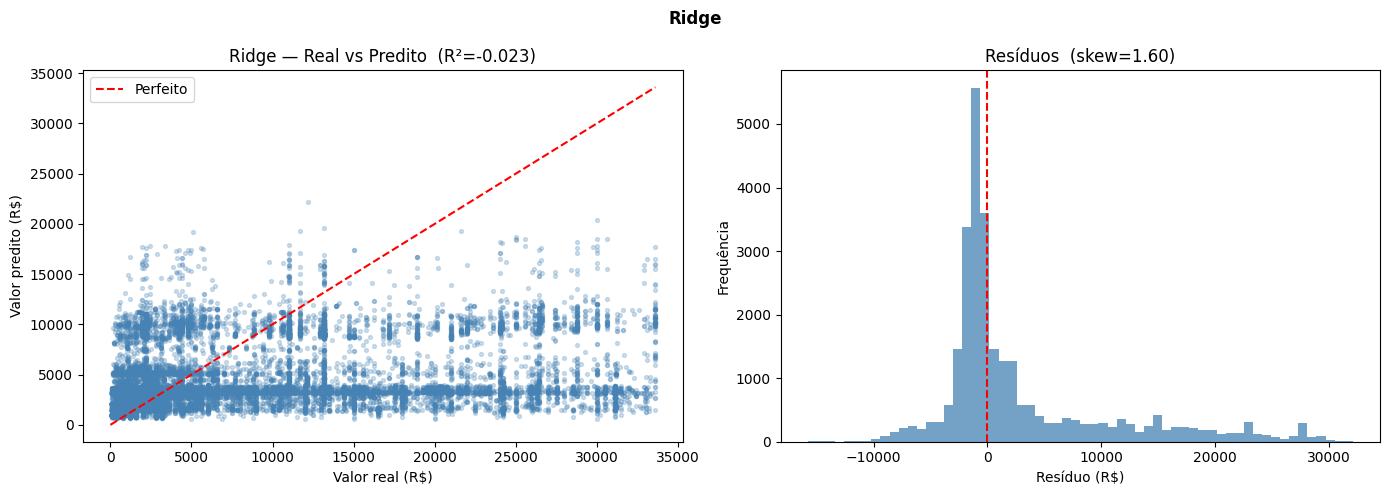

In [ ]:
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

print('Treinando Ridge...')
pipeline_ridge.fit(X_train, y_train)

pred_log_ridge  = pipeline_ridge.predict(X_test)
pred_real_ridge = avaliar('Ridge (baseline)', pred_log_ridge, y_test, y_test_raw.values)
plot_diagnostico('Ridge', y_test_raw.values, pred_real_ridge)


## 8. XGBoost + Optuna

Busca com `N_TRIALS_XGB` trials usando KFold no conjunto de treino.  
O modelo final é retreinado em treino + validação com os melhores hiperparâmetros.


In [ ]:
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist',
    }
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', XGBRegressor(**params))])
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=1)
    return -np.mean(scores)


study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)
print(f'Iniciando Optuna XGBoost ({N_TRIALS_XGB} trials)...')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=True)
print(f'\nMelhor RMSE (log): {study_xgb.best_value:.4f}')
print('Melhores params:', study_xgb.best_params)


Iniciando Optuna XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Melhor RMSE (log): 0.6784
Melhores params: {'n_estimators': 1609, 'max_depth': 10, 'learning_rate': 0.037889456570325296, 'subsample': 0.8855387212502646, 'colsample_bytree': 0.8466562052456994, 'min_child_weight': 22, 'reg_alpha': 0.0010680481376251119, 'reg_lambda': 0.001048279763908468, 'gamma': 1.9463557537828895, 'colsample_bylevel': 0.8269207648344685}


XGBoost final treinado

RESULTADOS — XGBoost
MAE    : R$   3,072.62
RMSE   : R$   5,085.11
R² real: 0.6173
R² log : 0.7377


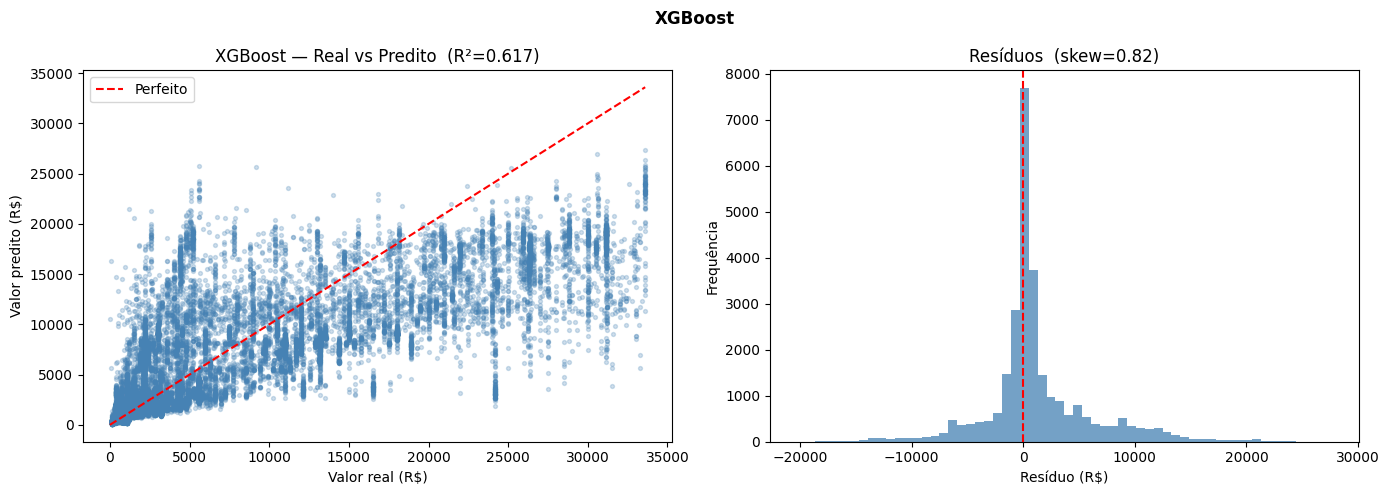

In [ ]:
# Retreina com treino + validação
X_trainval = pd.concat([X_train, X_valid])
y_trainval  = np.concatenate([y_train, y_valid])

final_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE,
                           n_jobs=-1, tree_method='hist'))
])
final_xgb.fit(X_trainval, y_trainval)
print('XGBoost final treinado')

pred_log_xgb  = final_xgb.predict(X_test)
pred_real_xgb = avaliar('XGBoost', pred_log_xgb, y_test, y_test_raw.values)
plot_diagnostico('XGBoost', y_test_raw.values, pred_real_xgb)


## H2:
A distribuição futura de investimentos pode ser estimada a partir
de padrões históricos de financiamento regional.

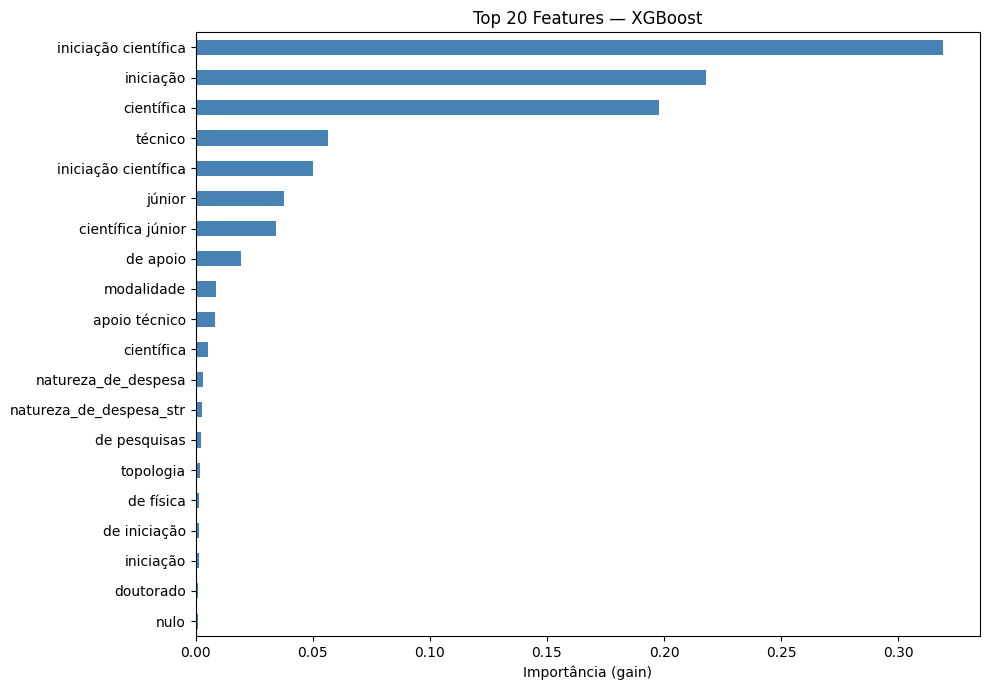

In [ ]:
# Importância de features — XGBoost
try:
    xgb_model  = final_xgb.named_steps['model']
    prep       = final_xgb.named_steps['preprocessor']
    feat_names = [f.split('__')[-1] for f in prep.get_feature_names_out()]
    importances = pd.Series(xgb_model.feature_importances_,
                            index=feat_names[:len(xgb_model.feature_importances_)]).sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    importances.head(20).plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title('Top 20 Features — XGBoost')
    plt.xlabel('Importância (gain)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Feature importance não disponível: {e}')


## 10. LightGBM + Optuna 

LightGBM usa o mesmo pré-processador que XGBoost (TF-IDF + Encoders),  
com vantagens de velocidade e suporte nativo a categóricas via `categorical_feature`.


In [ ]:
def objective_lgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 2000),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':   trial.suggest_int('subsample_freq', 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'boosting_type':    trial.suggest_categorical('boosting_type', ['gbdt', 'dart']),
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
        'verbose':          -1,
    }
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', LGBMRegressor(**params))])
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipeline, X_train, y_train, cv=kf,
                             scoring='neg_root_mean_squared_error', n_jobs=1)
    return -np.mean(scores)


study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)
print(f'Iniciando Optuna LightGBM ({N_TRIALS_LGB} trials)...')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_LGB, show_progress_bar=True)
print(f'\nMelhor RMSE (log): {study_lgb.best_value:.4f}')
print('Melhores params:', study_lgb.best_params)


Iniciando Optuna LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Melhor RMSE (log): 0.6786
Melhores params: {'n_estimators': 440, 'num_leaves': 186, 'max_depth': 11, 'learning_rate': 0.011053680743012075, 'subsample': 0.9264274099779043, 'subsample_freq': 4, 'colsample_bytree': 0.8440717591397843, 'min_child_samples': 41, 'reg_alpha': 0.05894510267522181, 'reg_lambda': 0.13479734883338368, 'boosting_type': 'gbdt'}


LightGBM final treinado

RESULTADOS — LightGBM
MAE    : R$   3,090.55
RMSE   : R$   5,109.80
R² real: 0.6136
R² log : 0.7373


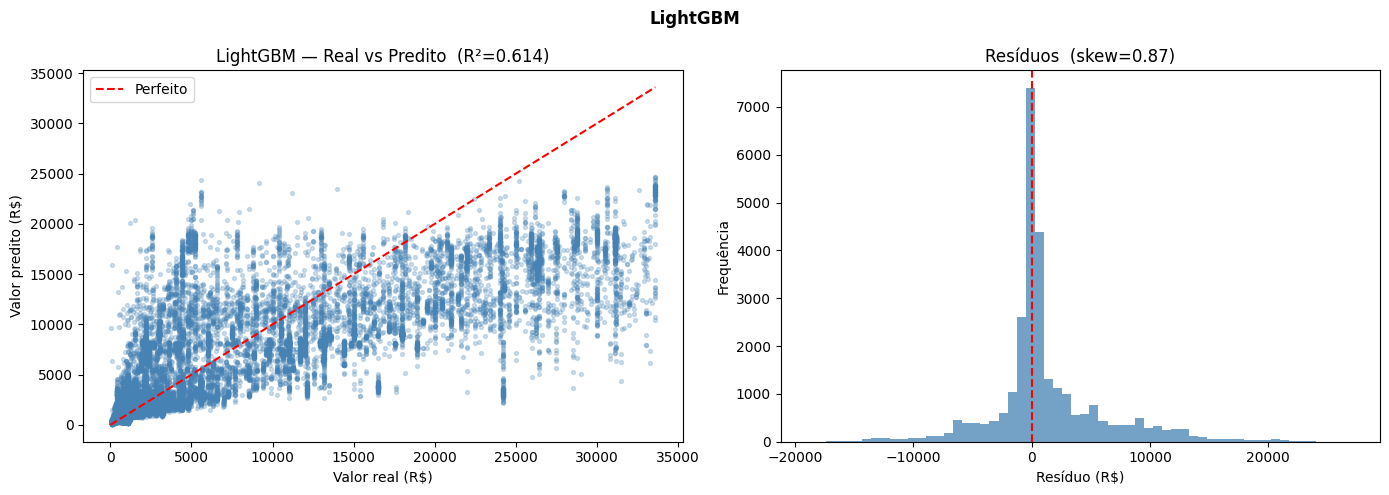

In [ ]:
# Retreina LightGBM com treino + validação
final_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_STATE,
                            n_jobs=-1, verbose=-1))
])
final_lgb.fit(X_trainval, y_trainval)
print('LightGBM final treinado')

pred_log_lgb  = final_lgb.predict(X_test)
pred_real_lgb = avaliar('LightGBM', pred_log_lgb, y_test, y_test_raw.values)
plot_diagnostico('LightGBM', y_test_raw.values, pred_real_lgb)


## H2:
A distribuição futura de investimentos pode ser estimada a partir
de padrões históricos de financiamento regional.

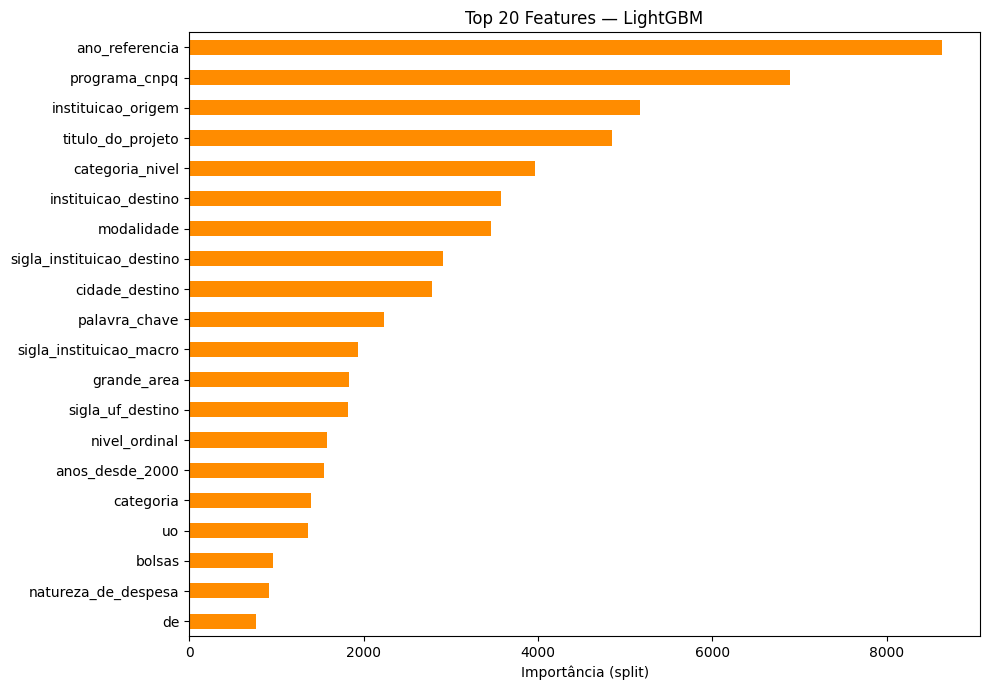

In [ ]:
# Importância de features — LightGBM
try:
    lgb_model   = final_lgb.named_steps['model']
    prep        = final_lgb.named_steps['preprocessor']
    feat_names  = [f.split('__')[-1] for f in prep.get_feature_names_out()]
    importances = pd.Series(lgb_model.feature_importances_,
                            index=feat_names[:len(lgb_model.feature_importances_)]).sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    importances.head(20).plot(kind='barh', color='darkorange')
    plt.gca().invert_yaxis()
    plt.title('Top 20 Features — LightGBM')
    plt.xlabel('Importância (split)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Feature importance não disponível: {e}')


## 11. TabPFN-3


In [ ]:
# TabPFN-3 (Zero Tuning)
# TabPFN exige entrada densa
# convertemos aqui caso o preprocessor retorne matriz esparsa.


class DenseTransformer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "toarray"):
            return X.toarray()
        return X
    def fit_transform(self, X, y=None):
        return self.transform(X)

pipeline_tabpfn = Pipeline([
    ('preprocessor', preprocessor_tabpfn),
    ('to_dense', DenseTransformer()),
    ('model', TabPFNRegressor(
        n_estimators=8,
        random_state=RANDOM_STATE,
        ignore_pretraining_limits=False
    ))
])

print('Treinando TabPFN-3 (fit é quase instantâneo)')
pipeline_tabpfn.fit(X_train, y_train)

print('Predizendo no teste (o predict em CPU pode levar alguns minutos dependendo de N_SAMPLE)')
pred_log_tabpfn = pipeline_tabpfn.predict(X_test)

# Avalia e plota os diagnósticos 
pred_real_tabpfn = avaliar('TabPFN-3', pred_log_tabpfn, y_test, y_test_raw.values)
plot_diagnostico('TabPFN-3', y_test_raw.values, pred_real_tabpfn)



Treinando TabPFN-3 (fit é quase instantâneo)
Predizendo no teste (o predict em CPU pode levar alguns minutos dependendo de N_SAMPLE)


: 

: 

Treinando TabPFN-3 (fit é quase instantâneo)
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


14:44 Fitting... Done!
Predizendo no teste (o predict em CPU pode levar alguns minutos dependendo de N_SAMPLE)
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:52 Predicting... Done!

RESULTADOS — TabPFN-3
MAE    : R$   3,130.70
RMSE   : R$   5,162.43
R² real: 0.6223
R² log : 0.7319


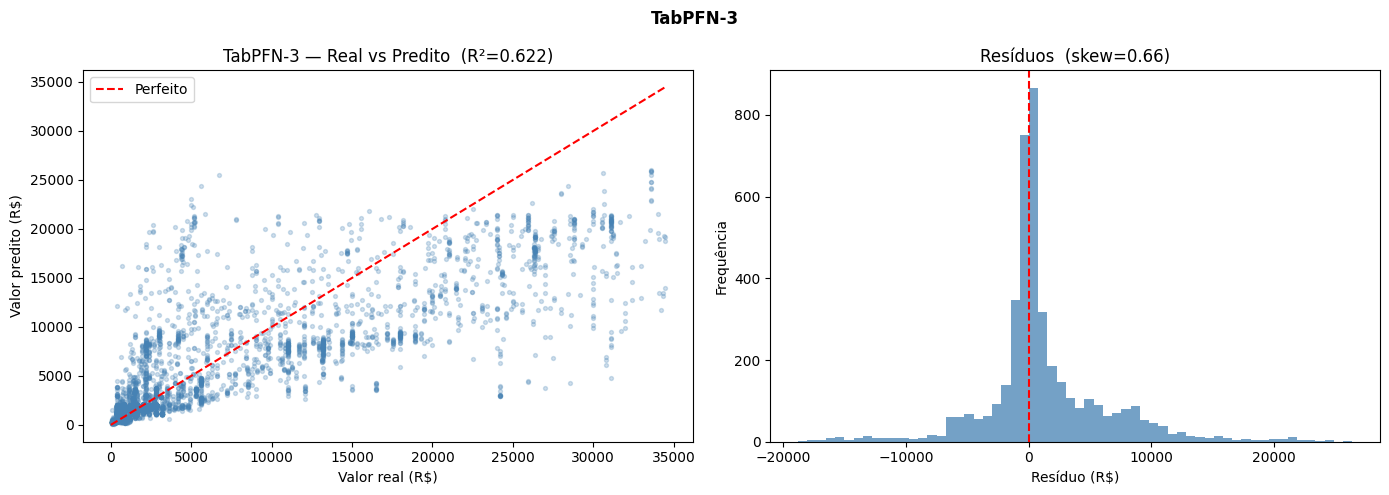

In [ ]:
# TabPFN-3 (Zero Tuning)
# TabPFN exige entrada densa
# convertemos aqui caso o preprocessor retorne matriz esparsa.
from tabpfn_client import TabPFNRegressor
from sklearn.pipeline import Pipeline

class DenseTransformer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "toarray"):
            return X.toarray()
        return X
    def fit_transform(self, X, y=None):
        return self.transform(X)

pipeline_tabpfn = Pipeline([
    ('preprocessor', preprocessor_tabpfn),
    ('to_dense', DenseTransformer()),
    ('model', TabPFNRegressor(
        thinking_mode=True,          
        thinking_effort="high",      
        thinking_metric="r2",
    ))
])

print('Treinando TabPFN-3 (fit é quase instantâneo)')
pipeline_tabpfn.fit(X_train, y_train)

print('Predizendo no teste (o predict em CPU pode levar alguns minutos dependendo de N_SAMPLE)')
pred_log_tabpfn = pipeline_tabpfn.predict(X_test)

# Avalia e plota os diagnósticos 
pred_real_tabpfn = avaliar('TabPFN-3', pred_log_tabpfn, y_test, y_test_raw.values)
plot_diagnostico('TabPFN-3', y_test_raw.values, pred_real_tabpfn)



## Random Forest

In [ ]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),   # era até 591
        'max_depth': trial.suggest_int('max_depth', 5, 15),             # era até 27
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(**params, random_state=42, n_jobs=1))
    ])
    
    # Reduz de 5 para 3 folds na busca
    scores = cross_val_score(pipeline, X_train, y_train, cv=3,
                             scoring='neg_root_mean_squared_error', n_jobs=1)
    return -scores.mean()

study_rf = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)
print(f'Iniciando Optuna Random Forest ({N_TRIALS_RF} trials)...')
study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)
print(f'\nMelhor RMSE (log): {study_rf.best_value:.4f}')
print('Melhores params:', study_rf.best_params)

Iniciando Optuna Random Forest (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


Melhor RMSE (log): 0.7125
Melhores params: {'n_estimators': 262, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [ ]:
# random forest com melhores params
final_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE))])
final_rf.fit(X_trainval, y_trainval)
print('Random Forest final treinado')
pred_log_rf  = final_rf.predict(X_test)
pred_real_rf = avaliar('Random Forest', pred_log_rf, y_test, y_test_raw.values)

Random Forest final treinado

RESULTADOS — Random Forest
MAE    : R$   3,401.98
RMSE   : R$   5,713.40
R² real: 0.5374
R² log : 0.7114


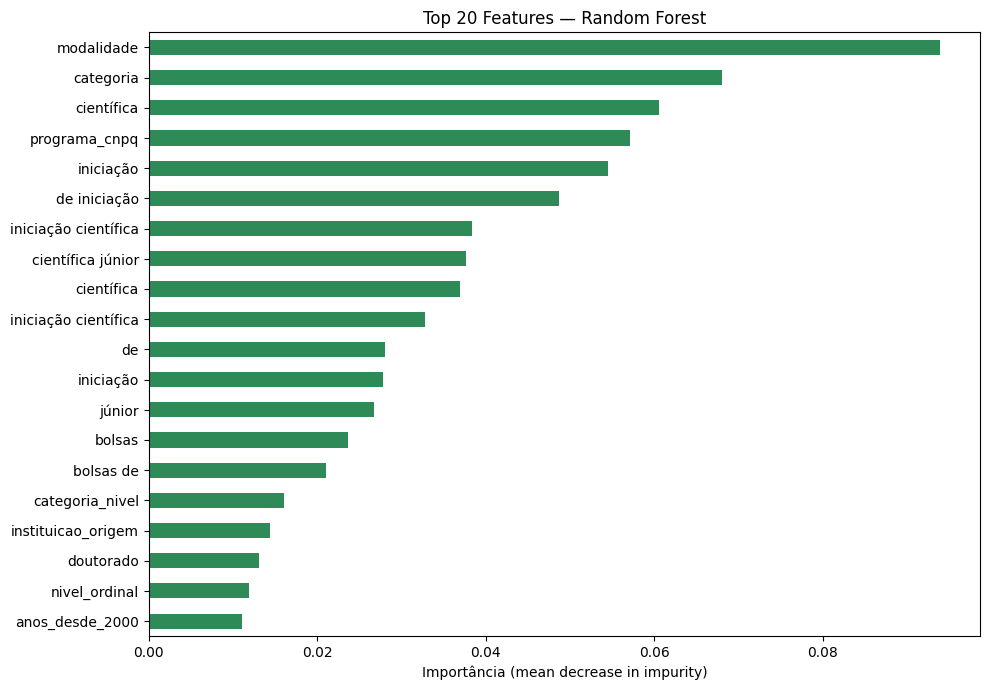

In [ ]:
# importancia de features — Random Forest

try:
    rf_model   = final_rf.named_steps['model']
    prep       = final_rf.named_steps['preprocessor']
    feat_names = [f.split('__')[-1] for f in prep.get_feature_names_out()]
    importances = pd.Series(rf_model.feature_importances_,
                            index=feat_names[:len(rf_model.feature_importances_)]).sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    importances.head(20).plot(kind='barh', color='seagreen')
    plt.gca().invert_yaxis()
    plt.title('Top 20 Features — Random Forest')
    plt.xlabel('Importância (mean decrease in impurity)')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Feature importance não disponível: {e}')

## 11. Tabela comparativa final

Reúne todos os modelos testados nesta sessão.


In [ ]:
df_res = pd.DataFrame(resultados).sort_values('R²_real', ascending=False).reset_index(drop=True)
df_res['MAE']  = df_res['MAE'].map('R$ {:>10,.2f}'.format)
df_res['RMSE'] = df_res['RMSE'].map('R$ {:>10,.2f}'.format)
df_res['R²_real'] = df_res['R²_real'].map('{:.4f}'.format)
df_res['R²_log']  = df_res['R²_log'].map('{:.4f}'.format)
print('\n' + '=' * 70)
print('COMPARATIVO FINAL — todos os modelos')
print('=' * 70)
print(df_res.to_string(index=False))



COMPARATIVO FINAL — todos os modelos
          Modelo           MAE          RMSE R²_real R²_log
        TabPFN-3 R$   3,130.21 R$   5,174.24  0.6206 0.7308
         XGBoost R$   3,250.21 R$   5,349.90  0.5944 0.7241
        LightGBM R$   3,272.24 R$   5,395.79  0.5874 0.7216
   Random Forest R$   3,401.98 R$   5,713.40  0.5374 0.7114
Ridge (baseline) R$   5,110.28 R$   8,522.20 -0.0292 0.1840


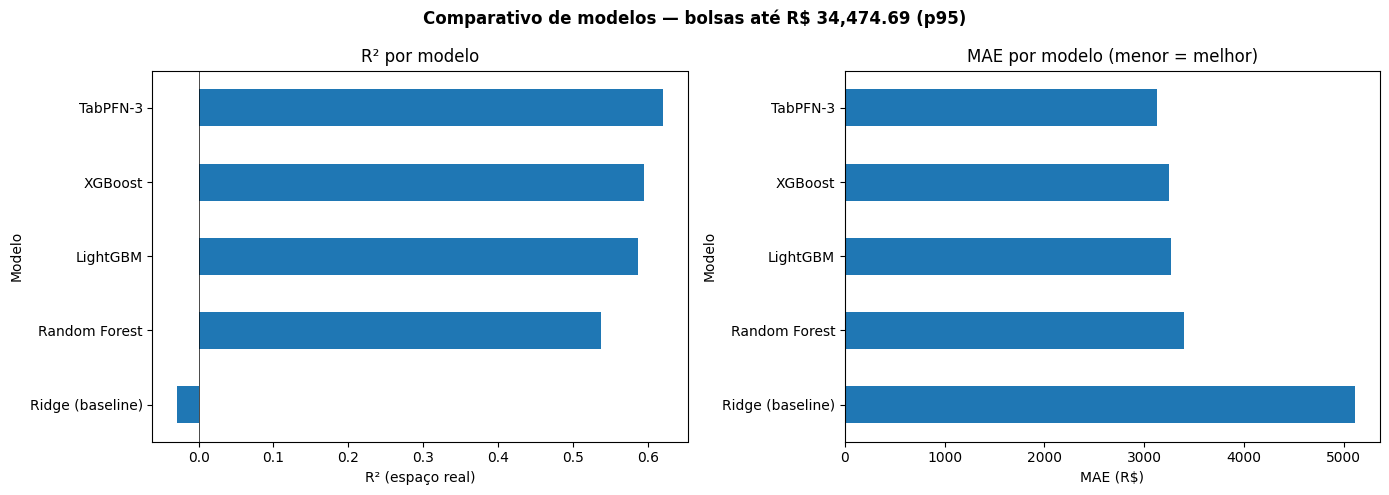

In [ ]:
# Gráfico comparativo de R² real
df_plot = pd.DataFrame(resultados).sort_values('R²_real', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot.plot(kind='barh', x='Modelo', y='R²_real', ax=axes[0],  legend=False)
axes[0].set_xlabel('R² (espaço real)')
axes[0].set_title('R² por modelo')
axes[0].axvline(0, color='black', linewidth=0.5)

# MAE numérico para plot
df_mae = pd.DataFrame(resultados).sort_values('MAE', ascending=False)
df_mae.plot(kind='barh', x='Modelo', y='MAE', ax=axes[1],
            legend=False)
axes[1].set_xlabel('MAE (R$)')
axes[1].set_title('MAE por modelo (menor = melhor)')

plt.suptitle(f'Comparativo de modelos — bolsas até R$ {teto:,.2f} (p95)', fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Salvando o melhor modelo

Descomente o bloco abaixo para persistir o modelo vencedor.


In [ ]:
import joblib

 # Identifica o melhor modelo pelo R² real
best_name = pd.DataFrame(resultados).sort_values('R²_real', ascending=False).iloc[0]['Modelo']
best_model_map = {
     'Ridge (baseline)': pipeline_ridge,
     'XGBoost':          final_xgb,
     'LightGBM':         final_lgb,
     'TabPFN-3':         pipeline_tabpfn,  
}
best_pipeline = best_model_map[best_name]
joblib.dump(best_pipeline, f'modelo_cnpq_{best_name.lower()}.pkl')
print(f'Melhor modelo ({best_name}) salvo')


Melhor modelo (TabPFN-3) salvo
